In [1]:
import rush_hour_rl as rl
import rush_hour_lib as lib

In [2]:
puzzles = lib.sample_unique()
puzzle = puzzles[20]

In [3]:
# cars = list(puzzle)
# env = rl.Environment((6, 6), cars)
# agent = rl.DQNAgent([name for name, _ in cars])
# trainer = rl.DQNTrain(agent, env)

In [4]:
# trainer = rl.DQNTrain(agent, env, blocker_threshold=2)

In [5]:
# trainer.learn(10000)

In [6]:
# rl.plot_training_results({"blocker threshold = 2": trainer.history}, "visualization/solver_10000.png")

## Apprentice/teacher (ExIt) model on the distance-20 puzzle

Same `puzzle` (distance 20) as above, but trained via `train_policy_dagger` (supervised imitation of AND-OR, with DAgger aggregation) instead of the DQN pipeline. 10000 total AND-OR solve attempts, split as 3000 for the initial behavior-cloning batch + 5 DAgger rounds x 1400 rollouts each. `guide_and_or=True` so from round 1 onward, AND-OR's own candidate ordering is guided by the agent's current heuristic instead of random search - the teacher improving from the apprentice, not just the reverse.

In [7]:
apprentice_cars = [name for name, _ in puzzle]
apprentice_initial = [(name, list(positions)) for name, positions in puzzle]


In [ ]:
agent, examples, round_stats = rl.train_policy_dagger(
    apprentice_cars, apprentice_initial, (6, 6),
    n_iterations=5, n_initial_traces=3000, n_rollouts_per_round=1400,
    epochs_per_round=20, max_steps=200,
    guide_and_or=True, and_or_eval_trials=30,
)
rl.print_round_stats(round_stats)


DAgger rounds:  80%|████████  | 4/5 [10:57<02:44, 164.30s/it, examples=694478, policy_solved=0, value_solved=1]

(0, 277867, 1.9874212729204426, 24.305905617162857, False, None, True, 23, 0.9666666666666667, 94.3103448275862)
(1, 370549, 1.8732629460811472, 22.708527528170517, False, None, True, 89, 0.7, 107.19047619047619)
(2, 480125, 1.7506266492750768, 20.784015707991763, False, None, True, 39, 1.0, 116.33333333333333)
(3, 592720, 1.6790751814600877, 19.560479490579034, False, None, True, 22, 0.9333333333333333, 89.39285714285714)
(4, 694478, 1.6503979409144622, 19.313640698501445, False, None, True, 21, 0.9666666666666667, 97.93103448275862)


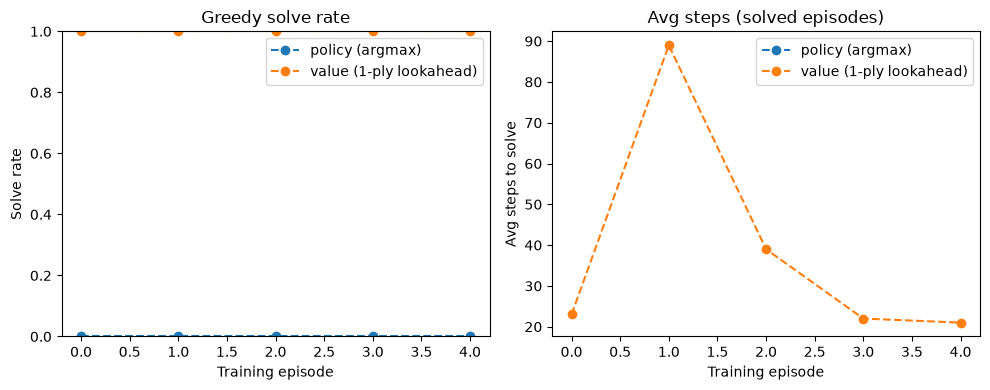

In [9]:
rl.plot_training_results({
    "policy (argmax)": [(r[0], float(r[4]), r[5] if r[5] is not None else float("nan")) for r in round_stats],
    "value (1-ply lookahead)": [(r[0], float(r[6]), r[7] if r[7] is not None else float("nan")) for r in round_stats],
}, "visualization/apprentice_10000.png")


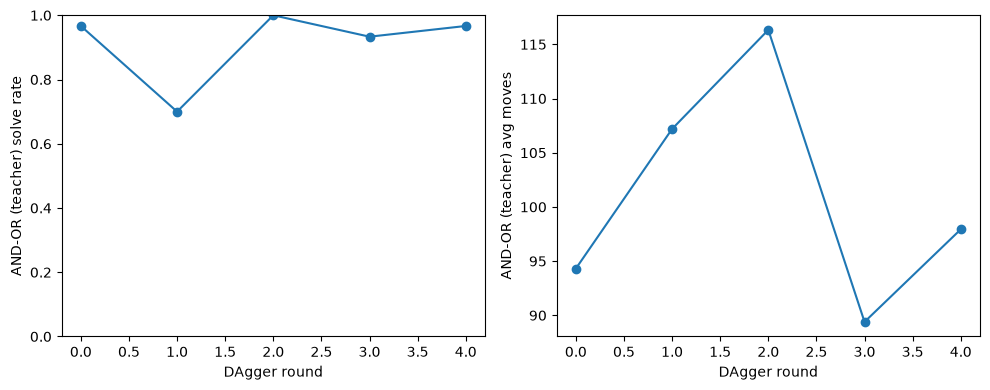

In [10]:
import matplotlib.pyplot as plt

rounds = [r[0] for r in round_stats]
and_or_solve_rate = [r[8] for r in round_stats]
and_or_avg_moves = [r[9] for r in round_stats]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(rounds, and_or_solve_rate, marker="o")
ax1.set_xlabel("DAgger round"); ax1.set_ylabel("AND-OR (teacher) solve rate"); ax1.set_ylim(0, 1)
ax2.plot(rounds, and_or_avg_moves, marker="o")
ax2.set_xlabel("DAgger round"); ax2.set_ylabel("AND-OR (teacher) avg moves")
plt.tight_layout()
plt.savefig("visualization/and_or_teacher_10000.png")
plt.show()
